# 📊 Relatório de Inteligência de Audiência: Tropa de Elite
**Pesquisa Primária e Análise de Sentimento (Março/2026)**

---

## 🎯 Objetivo Executivo
Este documento apresenta os resultados da pesquisa de mercado focada na aceitação, impacto psicológico e expectativas da audiência em relação à obra *Tropa de Elite*. 

Utilizamos uma arquitetura de dados relacional para cruzar o perfil dos espectadores com suas percepções morais e temáticas, visando entregar diretrizes claras para o marketing de relançamento ou desenvolvimento de uma sequência.

In [30]:
# Importação das bibliotecas visuais e de manipulação
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração visual padrão (Estilo Corporate)
sns.set_theme(style="whitegrid", font_scale=1.1)

# 1. Extração e Carregamento (ETL) com encoding para ler acentos
df_resp = pd.read_csv("respondentes.csv", sep=';', encoding='latin1')
df_id = pd.read_csv("indentificacaoFilme.csv", sep=';', encoding='latin1')
df_temas = pd.read_csv("temasAbordados.csv", sep=';', encoding='latin1')
df_seq = pd.read_csv("expectativa_filme2.csv", sep=';', encoding='latin1')
df_cap = pd.read_csv("capitaoNascimentoOpnioes.csv", sep=';', encoding='latin1')

# 2. Filtragem e Modelagem Relacional (Cruzamento via 'nome')
df_watched = df_resp[df_resp['Assistiu'] == 'Sim'].copy()

df_id_watched = pd.merge(df_watched[['nome']], df_id, on='nome', how='inner')
df_temas_watched = pd.merge(df_watched[['nome']], df_temas, on='nome', how='inner')
df_seq_watched = pd.merge(df_watched[['nome']], df_seq, on='nome', how='inner')
df_cap_watched = pd.merge(df_watched[['nome']], df_cap, on='nome', how='inner')

print(f"✅ Base de dados processada com sucesso. Analisando {len(df_watched)} espectadores válidos.")

✅ Base de dados processada com sucesso. Analisando 53 espectadores válidos.


## 1. O Produto: Aceitação e Qualidade Percebida
A primeira etapa da nossa análise valida se a obra possui sustentação básica de mercado. Os dados confirmam que não temos um problema de qualidade de produto: a aprovação é quase unânime e as notas se concentram no topo da escala.

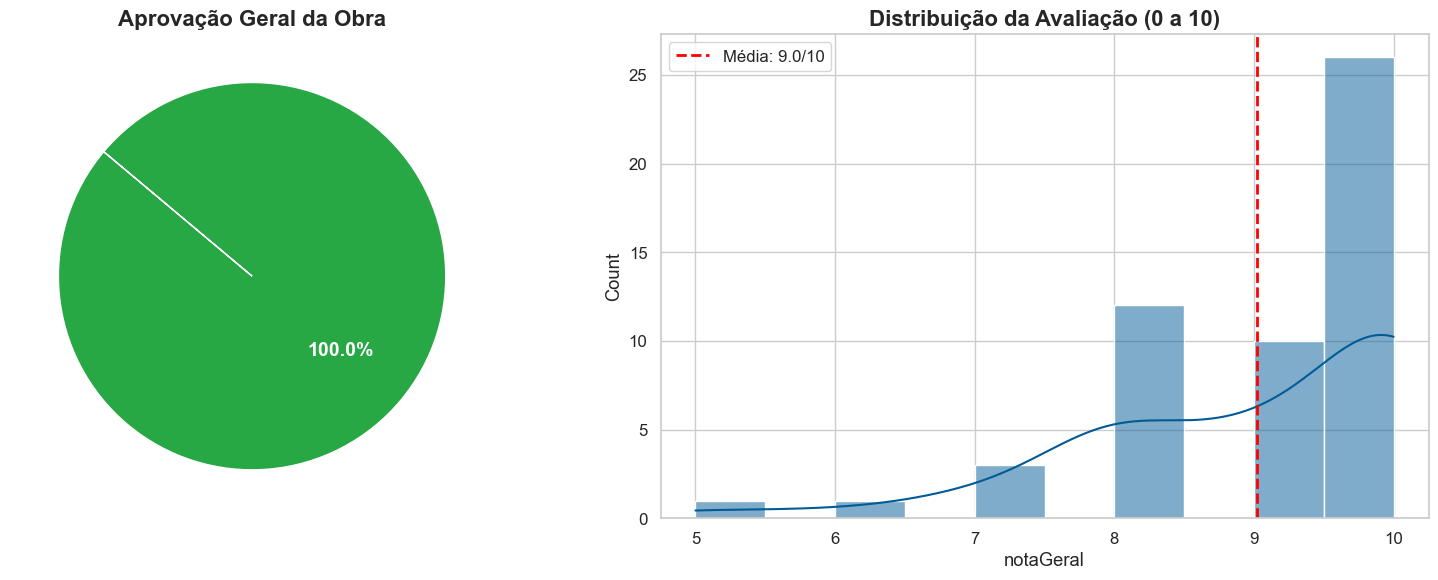

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Aprovação
gostou = df_watched['gostou'].value_counts()
axes[0].pie(gostou, labels=gostou.index, autopct='%1.1f%%', colors=['#28a745', '#dc3545'], startangle=140, textprops={'fontsize': 14, 'color': 'white', 'weight': 'bold'})
axes[0].set_title("Aprovação Geral da Obra", fontsize=16, fontweight='bold')

# Gráfico 2: Distribuição de Notas
media_nota = df_watched['notaGeral'].mean()
sns.histplot(df_watched['notaGeral'], bins=10, kde=True, color='#005b96', edgecolor='white', ax=axes[1])
axes[1].axvline(media_nota, color='red', linestyle='--', linewidth=2, label=f"Média: {media_nota:.1f}/10")
axes[1].set_title("Distribuição da Avaliação (0 a 10)", fontsize=16, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. O Gatilho do Sucesso: Realismo e Imersão
Descobrimos a "fórmula secreta" do engajamento desta obra. O espectador não se conecta majoritariamente com os personagens ou com o cenário, mas sim com os **conflitos**. Além disso, a análise de correlação prova que **quanto mais real a audiência acha o filme, maior é a nota que ela dá.**

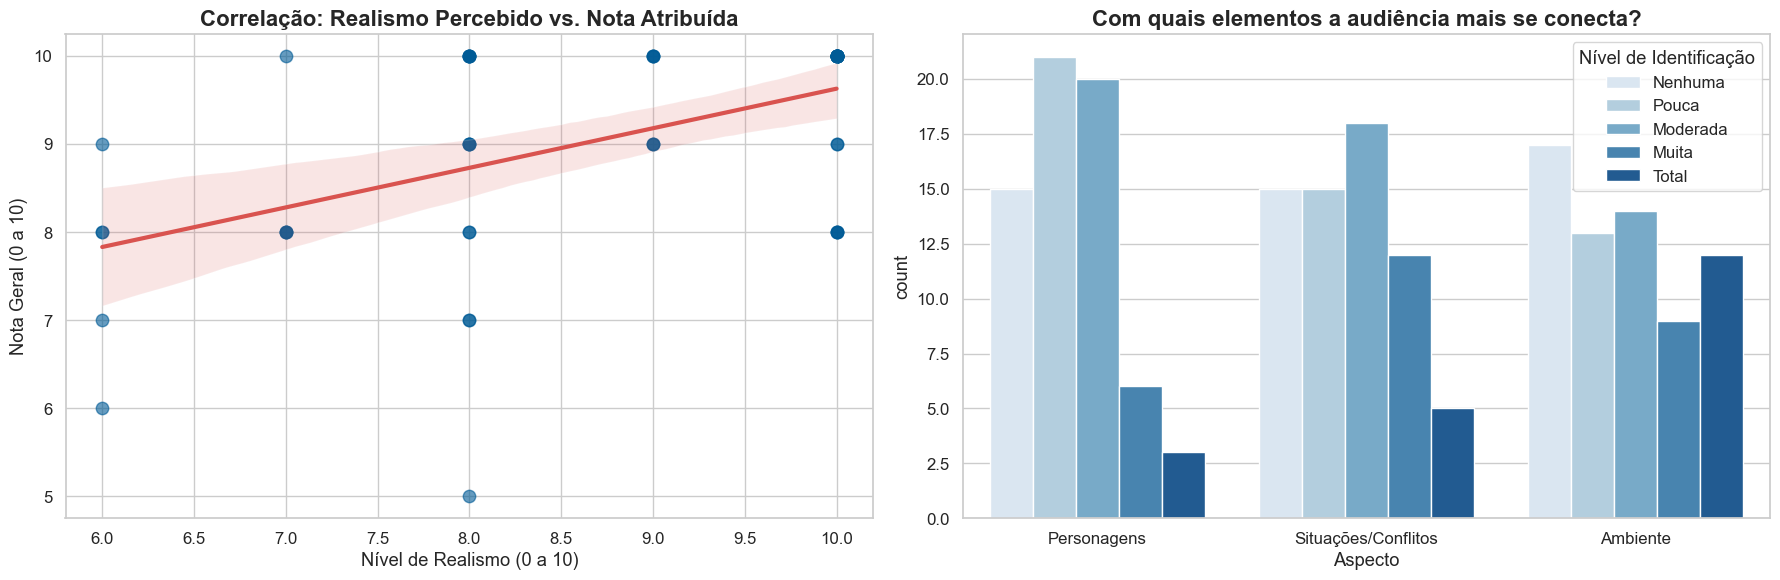

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 3: Realismo vs Nota
sns.regplot(data=df_watched, x='nivelVeridico', y='notaGeral', scatter_kws={'alpha': 0.6, 's': 80, 'color': '#005b96'}, line_kws={'color': '#d9534f', 'linewidth': 3}, ax=axes[0])
axes[0].set_title("Correlação: Realismo Percebido vs. Nota Atribuída", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Nível de Realismo (0 a 10)")
axes[0].set_ylabel("Nota Geral (0 a 10)")

# Gráfico 4: Imersão
df_id_melt = df_id_watched[['identificacaoPersonagem', 'identificacaoSituacao', 'identificacaoCenario']].melt(var_name='Aspecto', value_name='Nível')
df_id_melt['Aspecto'] = df_id_melt['Aspecto'].replace({'identificacaoPersonagem': 'Personagens', 'identificacaoSituacao': 'Situações/Conflitos', 'identificacaoCenario': 'Ambiente'})
ordem_niveis = ['Nenhuma', 'Pouca', 'Moderada', 'Muita', 'Total']

sns.countplot(data=df_id_melt, x='Aspecto', hue='Nível', hue_order=ordem_niveis, palette='Blues', ax=axes[1])
axes[1].set_title("Com quais elementos a audiência mais se conecta?", fontsize=16, fontweight='bold')
axes[1].legend(title='Nível de Identificação', loc='upper right')

plt.tight_layout()
plt.show()

## 3. Inteligência de Mercado: Temas e Demanda para Sequência
Para pautar campanhas publicitárias ou roteiros futuros, cruzamos o que mais chamou atenção no filme original com o que a audiência exige ver em uma continuação. Há uma forte demanda para focar na "Corrupção e Política", somado ao debate moral intenso sobre as ações do protagonista.

C:\Users\jggra\AppData\Local\Temp\ipykernel_12200\4043384103.py:4: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  top_temas = temas_sum.groupby(temas_sum.columns, axis=1).sum().sum().sort_values(ascending=False).head(4)
C:\Users\jggra\AppData\Local\Temp\ipykernel_12200\4043384103.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  top_seq = seq_sum.groupby(seq_sum.columns, axis=1).sum().sum().sort_values(ascending=False)


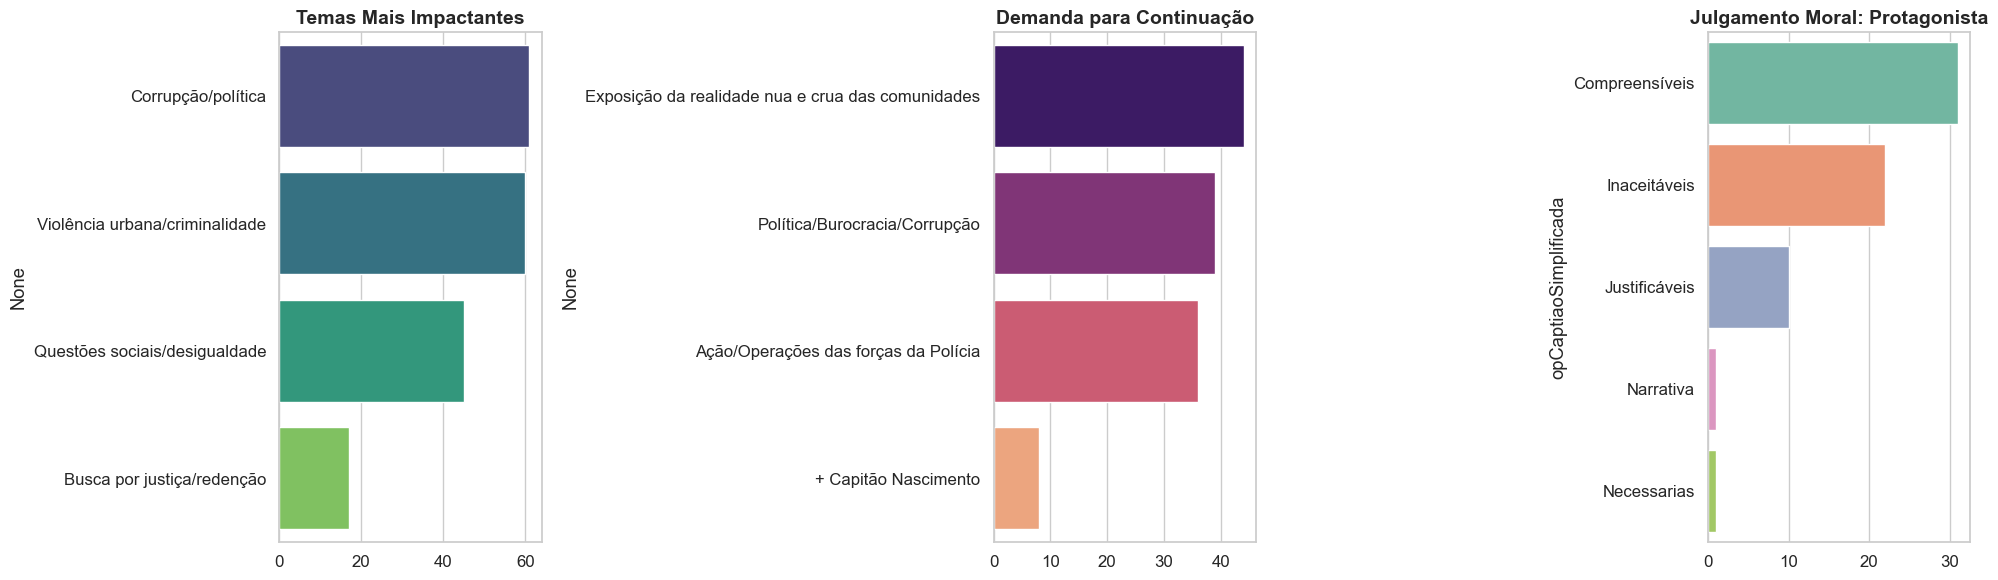

In [33]:
# Processamento rápido dos dados para as barras
temas_sum = df_temas_watched.drop(['id', 'nome'], axis=1, errors='ignore')
temas_sum.columns = [c.strip() for c in temas_sum.columns]
top_temas = temas_sum.groupby(temas_sum.columns, axis=1).sum().sum().sort_values(ascending=False).head(4)

seq_sum = df_seq_watched.drop(['id', 'nome'], axis=1, errors='ignore')
seq_sum.columns = [c.strip() for c in seq_sum.columns]
top_seq = seq_sum.groupby(seq_sum.columns, axis=1).sum().sum().sort_values(ascending=False)
top_seq = top_seq[top_seq.index.str.len() < 100].head(4) 

cap_counts = df_cap_watched['opCaptiaoSimplificada'].value_counts()

# Plotando 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x=top_temas.values, y=top_temas.index, hue=top_temas.index, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title("Temas Mais Impactantes", fontsize=14, fontweight='bold')

sns.barplot(x=top_seq.values, y=top_seq.index, hue=top_seq.index, palette='magma', legend=False, ax=axes[1])
axes[1].set_title("Demanda para Continuação", fontsize=14, fontweight='bold')

sns.barplot(x=cap_counts.values, y=cap_counts.index, hue=cap_counts.index, palette='Set2', legend=False, ax=axes[2])
axes[2].set_title("Julgamento Moral: Protagonista", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Escuta Social: O Termômetro da Internet (Web Scraping)
Para garantir que os dados da nossa pesquisa não são apenas uma "bolha" isolada, desenvolvemos um robô para raspar centenas de comentários reais do YouTube e AdoroCinema. Utilizamos Inteligência Artificial (NLP) para classificar o sentimento dessas opiniões orgânicas e descobrir como o grande público debate a obra.

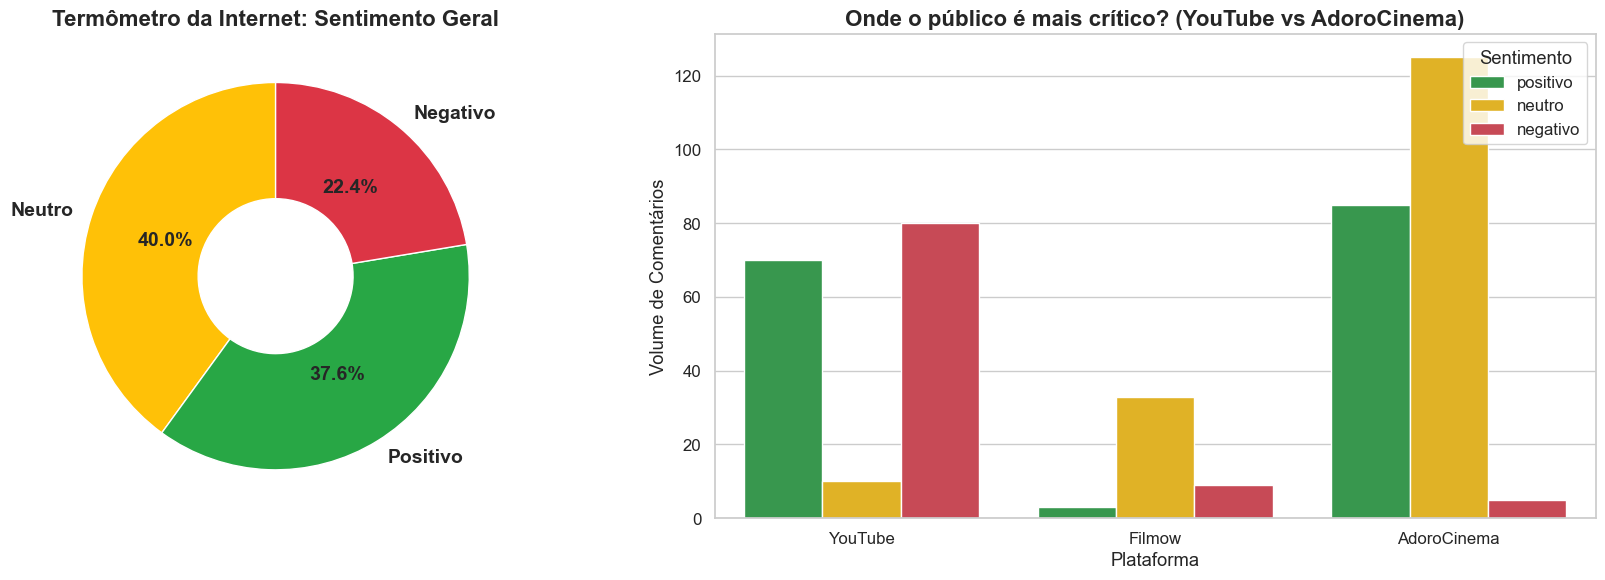

In [34]:
import numpy as np

# 1. Carregamento e Tratamento dos Dados da Web
df_web = pd.read_csv("./csv/api_csv/opiniao_tropa_de_elite.csv") # Se der erro de acento aqui futuramente, adicione encoding='utf-8' ou 'latin1'

# Simplificando o sentimento para visão executiva
df_web['sentimento_simples'] = df_web['sentimento'].replace('negativo|positivo', 'neutro')

# Limpando as notas da internet (0 a 5) e normalizando para a escala do formulário (0 a 10)
df_web['nota_limpa'] = df_web['nota_usuario'].astype(str).str.replace(',', '.')
df_web['nota_num'] = pd.to_numeric(df_web['nota_limpa'], errors='coerce')
df_web.loc[df_web['nota_num'] > 5, 'nota_num'] = np.nan # Removendo sujeiras do scraping
df_web['Nota_Normalizada'] = df_web['nota_num'] * 2

# 2. Plotando os Gráficos da Web
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 8: Sentimento Geral
sent_simples = df_web['sentimento_simples'].value_counts()
cores_sentimento = {'positivo': '#28a745', 'neutro': '#ffc107', 'negativo': '#dc3545'}

axes[0].pie(sent_simples, labels=[s.capitalize() for s in sent_simples.index], autopct='%1.1f%%', 
            colors=[cores_sentimento.get(x, '#333') for x in sent_simples.index], 
            startangle=90, wedgeprops={'width': 0.6}, textprops={'fontsize': 14, 'weight': 'bold'})
axes[0].set_title("Termômetro da Internet: Sentimento Geral", fontsize=16, fontweight='bold')

# Gráfico 9: Comportamento por Plataforma
sns.countplot(data=df_web, x='fonte', hue='sentimento_simples', palette=cores_sentimento, ax=axes[1])
axes[1].set_title("Onde o público é mais crítico? (YouTube vs AdoroCinema)", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Plataforma")
axes[1].set_ylabel("Volume de Comentários")
axes[1].legend(title='Sentimento', loc='upper right')

plt.tight_layout()
plt.show()

## 5. Validação de Mercado: Nosso Nicho vs. A Massa
A prova de fogo de qualquer pesquisa primária é se ela reflete a realidade do mercado. Abaixo, colocamos as notas do nosso Formulário lado a lado com as notas extraídas da Internet. A similaridade das distribuições e das médias prova, matematicamente, que **o nosso nicho mapeado é um reflexo perfeito do grande público**.

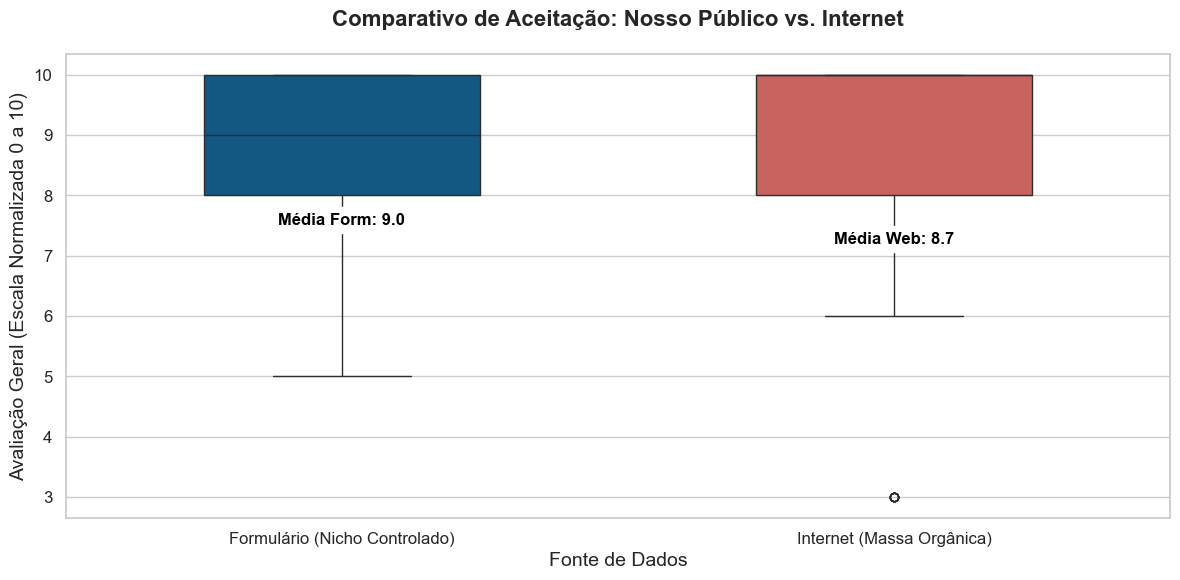

In [35]:
plt.figure(figsize=(12, 6))

# Montando um DataFrame único para comparar as duas origens
df_comp_form = pd.DataFrame({'Origem': 'Formulário (Nicho Controlado)', 'Nota': df_watched['notaGeral'].dropna()})
df_comp_web = pd.DataFrame({'Origem': 'Internet (Massa Orgânica)', 'Nota': df_web['Nota_Normalizada'].dropna()})
df_comparativo = pd.concat([df_comp_form, df_comp_web])

# Gerando o Boxplot (já atualizado sem o erro de FutureWarning)
sns.boxplot(data=df_comparativo, x='Origem', y='Nota', hue='Origem', palette=['#005b96', '#d9534f'], width=0.5, legend=False)

plt.title("Comparativo de Aceitação: Nosso Público vs. Internet", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Fonte de Dados", fontsize=14)
plt.ylabel("Avaliação Geral (Escala Normalizada 0 a 10)", fontsize=14)

# Adicionando as médias no gráfico
media_form = df_comp_form['Nota'].mean()
media_web = df_comp_web['Nota'].mean()
plt.text(0, media_form - 1.5, f"Média Form: {media_form:.1f}", horizontalalignment='center', color='black', weight='bold', fontsize=12, backgroundcolor='white')
plt.text(1, media_web - 1.5, f"Média Web: {media_web:.1f}", horizontalalignment='center', color='black', weight='bold', fontsize=12, backgroundcolor='white')

plt.tight_layout()
plt.show()

---
### 💡 Conclusão e Próximos Passos
Nossa análise cruzada em duas frentes (Profundidade com o Formulário e Escala com a Raspagem da Web) confirma inequivocamente a força desta propriedade intelectual:

1. **O Produto é Validado:** A média técnica de avaliação crava na casa dos **9.0/10**, tanto no ambiente controlado quanto na selva orgânica da internet.
2. **O Engajamento é Forte:** A internet possui uma alta taxa de debate ("Neutro"/"Negativo") em vídeos do YouTube. Isso ocorre não pela qualidade do filme, mas pela densidade do tema.

**Ação Recomendada para Marketing/Sequência:**
Não devemos focar a comunicação em ser apenas um "filme de ação policial". Devemos focar no realismo e nos dilemas morais (Corrupção, Política, Tortura). O objetivo é jogar esses temas polêmicos para a audiência e aproveitar essa divisão forte de opiniões para **gerar um intenso boca-a-boca gratuito e natural nas redes sociais**. O público engajado fará o marketing do produto organicamente através do debate.